In [ ]:
# Install required packages
%pip install pandas numpy matplotlib seaborn

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set visualization style for all plots
sns.set_theme(style="whitegrid", palette="muted")

# Define the directory where your 17 CSV files are stored
DATA_DIR = '../data/PRO-ACT_Data/2026_02_27_PROACT_ALL_FORMS/' 

# ---------------------------------------------------------
# 1. DATA LOADING
# ---------------------------------------------------------
def load_data(filename):
    """Safely load a CSV file into a pandas DataFrame."""
    file_path = os.path.join(DATA_DIR, filename)
    try:
        print(f"Loading {filename}...")
        return pd.read_csv(file_path, low_memory=False)
    except FileNotFoundError:
        print(f"  -> Warning: {filename} not found. Skipping.")
        return None

print("=== PART 1: LOADING DATASETS ===")
datasets = {
    'demographics': load_data('F_PROACT_DEMOGRAPHICS.csv'),
    'alsfrs': load_data('F_PROACT_ALSFRS.csv'),
    'death': load_data('F_PROACT_DEATHDATA.csv'),
    'treatment': load_data('F_PROACT_TREATMENT.csv'),
    'riluzole': load_data('F_PROACT_RILUZOLE.csv'),
    'fvc': load_data('F_PROACT_FVC.csv'),
    'svc': load_data('F_PROACT_SVC.csv'),
    'vitals': load_data('F_PROACT_VITALSIGNS.csv'),
    'handgrip': load_data('F_PROACT_HANDGRIPSTRENGTH.csv'),
    'muscle': load_data('F_PROACT_MUSCLESTRENGTH.csv'),
    'neurofilament': load_data('F_PROACT_Neurofilament.csv'),
    'adverse_events': load_data('F_PROACT_ADVERSEEVENTS.csv'),
    'history': load_data('F_PROACT_ALSHISTORY.csv'),
    'conmeds': load_data('F_PROACT_CONMEDS.csv'),
    'elescorial': load_data('F_PROACT_ELESCORIAL.csv'),
    'family': load_data('F_PROACT_FAMILYHISTORY.csv'),
    'labs': load_data('F_PROACT_LABS.csv')
}

# ---------------------------------------------------------
# 2. DATA CLEANING & STANDARDIZATION
# ---------------------------------------------------------
print("\n=== PART 2: CLEANING AND STANDARDIZING DATA ===")

if datasets['demographics'] is not None:
    datasets['demographics']['Age'] = pd.to_numeric(datasets['demographics']['Age'], errors='coerce')
    datasets['demographics']['Sex'] = datasets['demographics']['Sex'].astype(str).str.strip().str.title()

if datasets['alsfrs'] is not None:
    df = datasets['alsfrs']
    for col in ['ALSFRS_Delta', 'ALSFRS_Total']:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
    datasets['alsfrs'] = df.dropna(subset=['ALSFRS_Delta'], how='all')

if datasets['death'] is not None:
    datasets['death']['Death_Days'] = pd.to_numeric(datasets['death']['Death_Days'], errors='coerce')
    datasets['death']['Status'] = datasets['death']['Subject_Died'].apply(lambda x: 1 if str(x).strip().lower() == 'yes' else 0)

if datasets['treatment'] is not None:
    datasets['treatment']['Study_Arm'] = datasets['treatment']['Study_Arm'].astype(str).str.strip().str.title()

if datasets['riluzole'] is not None:
    datasets['riluzole']['Subject_used_Riluzole'] = datasets['riluzole']['Subject_used_Riluzole'].astype(str).str.strip().str.title()

if datasets['history'] is not None:
    datasets['history']['Site_of_Onset'] = datasets['history']['Site_of_Onset'].astype(str).str.strip().str.title()

if datasets['fvc'] is not None:
    datasets['fvc']['pct_of_Normal_Trial_1'] = pd.to_numeric(datasets['fvc']['pct_of_Normal_Trial_1'], errors='coerce')

if datasets['neurofilament'] is not None:
    datasets['neurofilament']['Result'] = pd.to_numeric(datasets['neurofilament']['Result'], errors='coerce')

if datasets['vitals'] is not None:
    datasets['vitals']['Weight'] = pd.to_numeric(datasets['vitals']['Weight'], errors='coerce')

if datasets['handgrip'] is not None:
    datasets['handgrip']['Test_Result'] = pd.to_numeric(datasets['handgrip']['Test_Result'], errors='coerce')
    datasets['handgrip']['MS_Delta'] = pd.to_numeric(datasets['handgrip']['MS_Delta'], errors='coerce')

if datasets['labs'] is not None:
    datasets['labs']['Test_Result'] = pd.to_numeric(datasets['labs']['Test_Result'], errors='coerce')
    datasets['labs']['Laboratory_Delta'] = pd.to_numeric(datasets['labs']['Laboratory_Delta'], errors='coerce')
    datasets['labs']['Test_Name'] = datasets['labs']['Test_Name'].astype(str).str.strip().str.upper()

# ---------------------------------------------------------
# 3. COMPREHENSIVE DATA EXPLORATION
# ---------------------------------------------------------
print("\n=== PART 3: DATA EXPLORATION (SUMMARY) ===")

def explore_dataframe(df, name):
    if df is not None:
        print(f"--- {name.upper()} ---")
        print(f"Total Rows: {df.shape[0]:,} | Total Columns: {df.shape[1]}")
        if 'subject_id' in df.columns:
            print(f"Unique Subjects: {df['subject_id'].nunique():,}")
        
        # Calculate sparsity (percentage of missing values)
        # FIXED: Using df.size instead of the deprecated np.product
        total_cells = df.size
        missing_cells = df.isnull().sum().sum()
        sparsity = (missing_cells / total_cells) * 100 if total_cells > 0 else 0
        print(f"Dataset Sparsity: {sparsity:.1f}% missing values overall")
        print("-" * 35)

for name, df in datasets.items():
    explore_dataframe(df, name)

# ---------------------------------------------------------
# 4. EXTENSIVE VISUALIZATIONS
# ---------------------------------------------------------
print("\n=== PART 4: GENERATING VISUALIZATIONS ===")
rlt_dir = '../PROACT_results/'
if not os.path.exists(rlt_dir):
    os.makedirs(rlt_dir)

# 1. Demographics: Age and Sex Distribution
if datasets['demographics'] is not None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    sns.histplot(datasets['demographics']['Age'].dropna(), bins=25, kde=True, color='#3498db', ax=axes[0])
    axes[0].set_title('Distribution of Age at Trial Entry', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Age (Years)')
    
    sns.countplot(data=datasets['demographics'], x='Sex', palette='pastel', ax=axes[1], order=['Male', 'Female'])
    axes[1].set_title('Distribution of Biological Sex', fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig(rlt_dir + '01_Demographics.png')
    plt.close()

# 2. ALS History: Site of Onset
if datasets['history'] is not None:
    plt.figure(figsize=(8, 5))
    valid_onset = datasets['history'][datasets['history']['Site_of_Onset'].str.contains('Onset', na=False)]
    if not valid_onset.empty:
        sns.countplot(data=valid_onset, y='Site_of_Onset', palette='viridis', order=valid_onset['Site_of_Onset'].value_counts().index)
        plt.title('Patient Site of Disease Onset', fontsize=12, fontweight='bold')
        plt.xlabel('Number of Patients')
        plt.ylabel('')
        plt.tight_layout()
        plt.savefig(rlt_dir + '02_Site_of_Onset.png')
    plt.close()

# 3. Treatment & Riluzole Distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
if datasets['treatment'] is not None and not datasets['treatment'].empty:
    t_counts = datasets['treatment']['Study_Arm'].value_counts()
    axes[0].pie(t_counts, labels=t_counts.index, autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c', '#f1c40f'])
    axes[0].set_title('Study Arm Assignment', fontweight='bold')
if datasets['riluzole'] is not None and not datasets['riluzole'].empty:
    r_counts = datasets['riluzole']['Subject_used_Riluzole'].value_counts()
    axes[1].pie(r_counts, labels=r_counts.index, autopct='%1.1f%%', colors=['#9b59b6', '#bdc3c7'])
    axes[1].set_title('Baseline Riluzole Usage', fontweight='bold')
plt.savefig(rlt_dir + '03_Treatment_Riluzole.png')
plt.close()

# 4. Disease Progression: ALSFRS Score over First 2 Years
if datasets['alsfrs'] is not None and not datasets['alsfrs'].empty:
    df_als = datasets['alsfrs']
    df_als_filt = df_als[(df_als['ALSFRS_Delta'] >= 0) & (df_als['ALSFRS_Delta'] <= 730)].copy()
    df_als_filt['Month'] = (df_als_filt['ALSFRS_Delta'] / 30).astype(int)
    monthly_trend = df_als_filt.groupby('Month')['ALSFRS_Total'].mean().reset_index()

    plt.figure(figsize=(10, 5))
    sns.lineplot(data=monthly_trend, x='Month', y='ALSFRS_Total', marker='o', color='#e67e22', linewidth=2.5)
    plt.title('Average ALSFRS Total Score Decline (First 2 Years)', fontsize=14, fontweight='bold')
    plt.xlabel('Months Since Trial Start')
    plt.ylabel('Average ALSFRS Total Score')
    plt.fill_between(monthly_trend['Month'], monthly_trend['ALSFRS_Total'] - 2, monthly_trend['ALSFRS_Total'] + 2, color='#e67e22', alpha=0.2)
    plt.savefig(rlt_dir + '04_ALSFRS_Progression.png')
    plt.close()

# 5. Respiratory Function: Baseline FVC Distribution
if datasets['fvc'] is not None and not datasets['fvc'].empty:
    plt.figure(figsize=(8, 5))
    sns.histplot(datasets['fvc']['pct_of_Normal_Trial_1'].dropna(), bins=30, color='#1abc9c', kde=True)
    plt.title('Baseline Forced Vital Capacity (FVC) % of Normal', fontsize=12, fontweight='bold')
    plt.xlabel('FVC (% of Normal)')
    plt.xlim(0, 150)
    plt.axvline(x=80, color='red', linestyle='--', label='Clinical Threshold (80%)')
    plt.legend()
    plt.savefig(rlt_dir + '05_FVC_Baseline.png')
    plt.close()

# 6. Biomarkers: Neurofilament 
if datasets['neurofilament'] is not None and not datasets['neurofilament'].empty:
    plt.figure(figsize=(8, 5))
    nf_95 = datasets['neurofilament']['Result'].quantile(0.95)
    clean_nf = datasets['neurofilament'][datasets['neurofilament']['Result'] <= nf_95]['Result'].dropna()
    sns.histplot(clean_nf, bins=40, color='#9b59b6', kde=True)
    plt.title('Neurofilament Light Chain Levels (pg/mL)', fontsize=12, fontweight='bold')
    plt.xlabel('Result (pg/mL)')
    plt.savefig(rlt_dir + '06_Neurofilament.png')
    plt.close()

# 7. Strength: Handgrip Over Time
if datasets['handgrip'] is not None and not datasets['handgrip'].empty:
    df_hg = datasets['handgrip']
    df_hg_filt = df_hg[(df_hg['MS_Delta'] >= 0) & (df_hg['MS_Delta'] <= 540)].copy()
    df_hg_filt['Month'] = (df_hg_filt['MS_Delta'] / 30).astype(int)
    monthly_hg = df_hg_filt.groupby('Month')['Test_Result'].mean().reset_index()

    plt.figure(figsize=(10, 5))
    sns.lineplot(data=monthly_hg, x='Month', y='Test_Result', marker='s', color='#27ae60', linewidth=2)
    plt.title('Average Handgrip Strength Decline (First 1.5 Years)', fontsize=12, fontweight='bold')
    plt.xlabel('Months Since Trial Start')
    plt.ylabel('Average Grip Strength (Pounds)')
    plt.savefig(rlt_dir + '07_Handgrip_Decline.png')
    plt.close()

# 8. Safety: Top 10 Most Common Adverse Events
if datasets['adverse_events'] is not None and not datasets['adverse_events'].empty:
    plt.figure(figsize=(10, 6))
    top_aes = datasets['adverse_events']['Preferred_Term'].value_counts().head(10)
    sns.barplot(x=top_aes.values, y=top_aes.index, palette='Reds_r')
    plt.title('Top 10 Most Frequent Adverse Events Reported', fontsize=12, fontweight='bold')
    plt.xlabel('Total Number of Occurrences')
    plt.tight_layout()
    plt.savefig(rlt_dir + '08_Adverse_Events.png')
    plt.close()

print("--> 8 visualization PNG files successfully saved to your directory.")

# ---------------------------------------------------------
# 5. FEATURE ENGINEERING & MASTER DATASET MERGE
# ---------------------------------------------------------
print("\n=== PART 5: BUILDING MASTER DATASET FOR ML ===")

# Initialize Master DF with unique subjects
master_df = pd.DataFrame()
if datasets['demographics'] is not None:
    master_df = pd.DataFrame({'subject_id': datasets['demographics']['subject_id'].unique()})

def merge_static_feature(master, df, columns):
    """Merges single-value (static) datasets into the master table."""
    if df is not None and not df.empty:
        # Drop duplicates to ensure a 1:1 merge per subject
        unique_df = df[['subject_id'] + columns].drop_duplicates(subset=['subject_id'])
        return pd.merge(master, unique_df, on='subject_id', how='left')
    return master

# Merge core static features
master_df = merge_static_feature(master_df, datasets['demographics'], ['Age', 'Sex'])
master_df = merge_static_feature(master_df, datasets['death'], ['Status', 'Death_Days'])
master_df = merge_static_feature(master_df, datasets['treatment'], ['Study_Arm'])
master_df = merge_static_feature(master_df, datasets['riluzole'], ['Subject_used_Riluzole'])
master_df = merge_static_feature(master_df, datasets['elescorial'], ['el_escorial'])
master_df = merge_static_feature(master_df, datasets['history'], ['Site_of_Onset'])

def get_baseline_longitudinal(df, delta_col, value_col, new_col_name):
    """Filters longitudinal data for the first ~30 days to establish a baseline average."""
    if df is not None and not df.empty and delta_col in df.columns and value_col in df.columns:
        baseline_data = df[(df[delta_col] >= 0) & (df[delta_col] <= 30)].copy()
        baseline_grouped = baseline_data.groupby('subject_id')[value_col].mean().reset_index()
        baseline_grouped.rename(columns={value_col: new_col_name}, inplace=True)
        return baseline_grouped
    return pd.DataFrame(columns=['subject_id', new_col_name])

# Merge Baseline Features from Time-Series Data
master_df = pd.merge(master_df, get_baseline_longitudinal(datasets['alsfrs'], 'ALSFRS_Delta', 'ALSFRS_Total', 'Baseline_ALSFRS'), on='subject_id', how='left')
master_df = pd.merge(master_df, get_baseline_longitudinal(datasets['fvc'], 'Forced_Vital_Capacity_Delta', 'pct_of_Normal_Trial_1', 'Baseline_FVC_pct'), on='subject_id', how='left')
master_df = pd.merge(master_df, get_baseline_longitudinal(datasets['vitals'], 'Vital_Signs_Delta', 'Weight', 'Baseline_Weight'), on='subject_id', how='left')

# Handle Large Lab Data
if datasets['labs'] is not None and not datasets['labs'].empty:
    df_labs = datasets['labs']
    baseline_labs = df_labs[(df_labs['Laboratory_Delta'] >= 0) & (df_labs['Laboratory_Delta'] <= 30)]
    
    key_labs = ['CREATININE', 'HEMOGLOBIN', 'WHITE BLOOD CELL (WBC)', 'ALKALINE PHOSPHATASE', 'SODIUM']
    filtered_labs = baseline_labs[baseline_labs['Test_Name'].isin(key_labs)]
    
    pivoted_labs = filtered_labs.pivot_table(index='subject_id', columns='Test_Name', values='Test_Result', aggfunc='mean').reset_index()
    pivoted_labs.columns = ['subject_id'] + [f"Lab_{str(col).replace(' ', '_')}" for col in pivoted_labs.columns[1:]]
    master_df = pd.merge(master_df, pivoted_labs, on='subject_id', how='left')

# ---------------------------------------------------------
# 6. FINAL REVIEW & EXPORT
# ---------------------------------------------------------
print("\n=== PART 6: EXPORT ===")
if not master_df.empty:
    print(f"Master Dataset Shape: {master_df.shape[0]:,} Rows (Patients) x {master_df.shape[1]} Columns (Features)")
    
    output_filename = 'PROACT_Master_Dataset.csv'
    master_df.to_csv(rlt_dir + output_filename, index=False)
    print(f"\nSUCCESS: Master dataset saved to '{output_filename}'")
else:
    print("Master dataset is empty. Ensure demographics data is available.")

=== PART 1: LOADING DATASETS ===
Loading F_PROACT_DEMOGRAPHICS.csv...
Loading F_PROACT_ALSFRS.csv...
Loading F_PROACT_DEATHDATA.csv...
Loading F_PROACT_TREATMENT.csv...
Loading F_PROACT_RILUZOLE.csv...
Loading F_PROACT_FVC.csv...
Loading F_PROACT_SVC.csv...
Loading F_PROACT_VITALSIGNS.csv...
Loading F_PROACT_HANDGRIPSTRENGTH.csv...
Loading F_PROACT_MUSCLESTRENGTH.csv...
Loading F_PROACT_Neurofilament.csv...
Loading F_PROACT_ADVERSEEVENTS.csv...
Loading F_PROACT_ALSHISTORY.csv...
Loading F_PROACT_CONMEDS.csv...
Loading F_PROACT_ELESCORIAL.csv...
Loading F_PROACT_FAMILYHISTORY.csv...
Loading F_PROACT_LABS.csv...

=== PART 2: CLEANING AND STANDARDIZING DATA ===

=== PART 3: DATA EXPLORATION (SUMMARY) ===
--- DEMOGRAPHICS ---
Total Rows: 13,115 | Total Columns: 14
Unique Subjects: 13,115
Dataset Sparsity: 63.5% missing values overall
-----------------------------------
--- ALSFRS ---
Total Rows: 81,041 | Total Columns: 20
Unique Subjects: 9,149
Dataset Sparsity: 28.0% missing values overal

/tmp/ipykernel_1691437/2061429965.py:133: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=datasets['demographics'], x='Sex', palette='pastel', ax=axes[1], order=['Male', 'Female'])
/tmp/ipykernel_1691437/2061429965.py:145: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=valid_onset, y='Site_of_Onset', palette='viridis', order=valid_onset['Site_of_Onset'].value_counts().index)
/tmp/ipykernel_1691437/2061429965.py:224: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_aes.values, y=top_aes.index, palette='Reds_r')


--> 8 visualization PNG files successfully saved to your directory.

=== PART 5: BUILDING MASTER DATASET FOR ML ===

=== PART 6: EXPORT ===
Master Dataset Shape: 13,115 Rows (Patients) x 17 Columns (Features)

SUCCESS: Master dataset saved to 'PROACT_Master_Dataset.csv'


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set visualization style for all plots
sns.set_theme(style="whitegrid", palette="muted")

# Define the directory where your 17 CSV files are stored
DATA_DIR = '../data/PRO-ACT_Data/2026_02_27_PROACT_ALL_FORMS/' 

# ---------------------------------------------------------
# 1. DATA LOADING
# ---------------------------------------------------------
def load_data(filename):
    """Safely load a CSV file into a pandas DataFrame."""
    file_path = os.path.join(DATA_DIR, filename)
    try:
        print(f"Loading {filename}...")
        return pd.read_csv(file_path, low_memory=False)
    except FileNotFoundError:
        print(f"  -> Warning: {filename} not found. Skipping.")
        return None

print("=== PART 1: LOADING DATASETS ===")
datasets = {
    'demographics': load_data('F_PROACT_DEMOGRAPHICS.csv'),
    'alsfrs': load_data('F_PROACT_ALSFRS.csv'),
    'death': load_data('F_PROACT_DEATHDATA.csv'),
    'treatment': load_data('F_PROACT_TREATMENT.csv'),
    'riluzole': load_data('F_PROACT_RILUZOLE.csv'),
    'fvc': load_data('F_PROACT_FVC.csv'),
    'svc': load_data('F_PROACT_SVC.csv'),
    'vitals': load_data('F_PROACT_VITALSIGNS.csv'),
    'handgrip': load_data('F_PROACT_HANDGRIPSTRENGTH.csv'),
    'muscle': load_data('F_PROACT_MUSCLESTRENGTH.csv'),
    'neurofilament': load_data('F_PROACT_Neurofilament.csv'),
    'adverse_events': load_data('F_PROACT_ADVERSEEVENTS.csv'),
    'history': load_data('F_PROACT_ALSHISTORY.csv'),
    'conmeds': load_data('F_PROACT_CONMEDS.csv'),
    'elescorial': load_data('F_PROACT_ELESCORIAL.csv'),
    'family': load_data('F_PROACT_FAMILYHISTORY.csv'),
    'labs': load_data('F_PROACT_LABS.csv')
}


=== PART 1: LOADING DATASETS ===
Loading F_PROACT_DEMOGRAPHICS.csv...
Loading F_PROACT_ALSFRS.csv...
Loading F_PROACT_DEATHDATA.csv...
Loading F_PROACT_TREATMENT.csv...
Loading F_PROACT_RILUZOLE.csv...
Loading F_PROACT_FVC.csv...
Loading F_PROACT_SVC.csv...
Loading F_PROACT_VITALSIGNS.csv...
Loading F_PROACT_HANDGRIPSTRENGTH.csv...
Loading F_PROACT_MUSCLESTRENGTH.csv...
Loading F_PROACT_Neurofilament.csv...
Loading F_PROACT_ADVERSEEVENTS.csv...
Loading F_PROACT_ALSHISTORY.csv...
Loading F_PROACT_CONMEDS.csv...
Loading F_PROACT_ELESCORIAL.csv...
Loading F_PROACT_FAMILYHISTORY.csv...
Loading F_PROACT_LABS.csv...


In [29]:
datasets["family"].head()

,subject_id,Family_History_Delta,Other_Specify,Family_Hx_of_ALS_Mutation,Family_Hx_of_ALS_Mutation_Other,Family_Hx_of_Neuro_Disease,Aunt,Aunt__Maternal_,Aunt__Paternal_,Cousin,...,Uncle,Uncle__Maternal_,Uncle__Paternal_,Family_Hx_of_Neuro_Disease_Other,Neurological_Disease,Neurological_Disease_Other,Son,Daughter,Sister,Brother
0,14339,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,51306,0.0,NaN,NaN,NaN,ALS,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,52690,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,PARKINSON'S DISEASE,NaN,NaN,NaN,NaN,NaN
3,56352,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,78204,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [34]:
datasets["alsfrs"].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 81229 entries, 0 to 81228
Data columns (total 20 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   subject_id                       81229 non-null  int64  
 1   Q1_Speech                        79926 non-null  float64
 2   Q2_Salivation                    79924 non-null  float64
 3   Q3_Swallowing                    79923 non-null  float64
 4   Q4_Handwriting                   79920 non-null  float64
 5   Q5a_Cutting_without_Gastrostomy  74348 non-null  float64
 6   Q5b_Cutting_with_Gastrostomy     6367 non-null   float64
 7   Q6_Dressing_and_Hygiene          79917 non-null  float64
 8   Q7_Turning_in_Bed                79916 non-null  float64
 9   Q8_Walking                       79920 non-null  float64
 10  Q9_Climbing_Stairs               79922 non-null  float64
 11  Q10_Respiratory                  36384 non-null  float64
 12  ALSFRS_Delta      

Cleaning and preparing ALSFRS data...
Generating Figure 1: Profile plots for 50 randomly selected individuals...


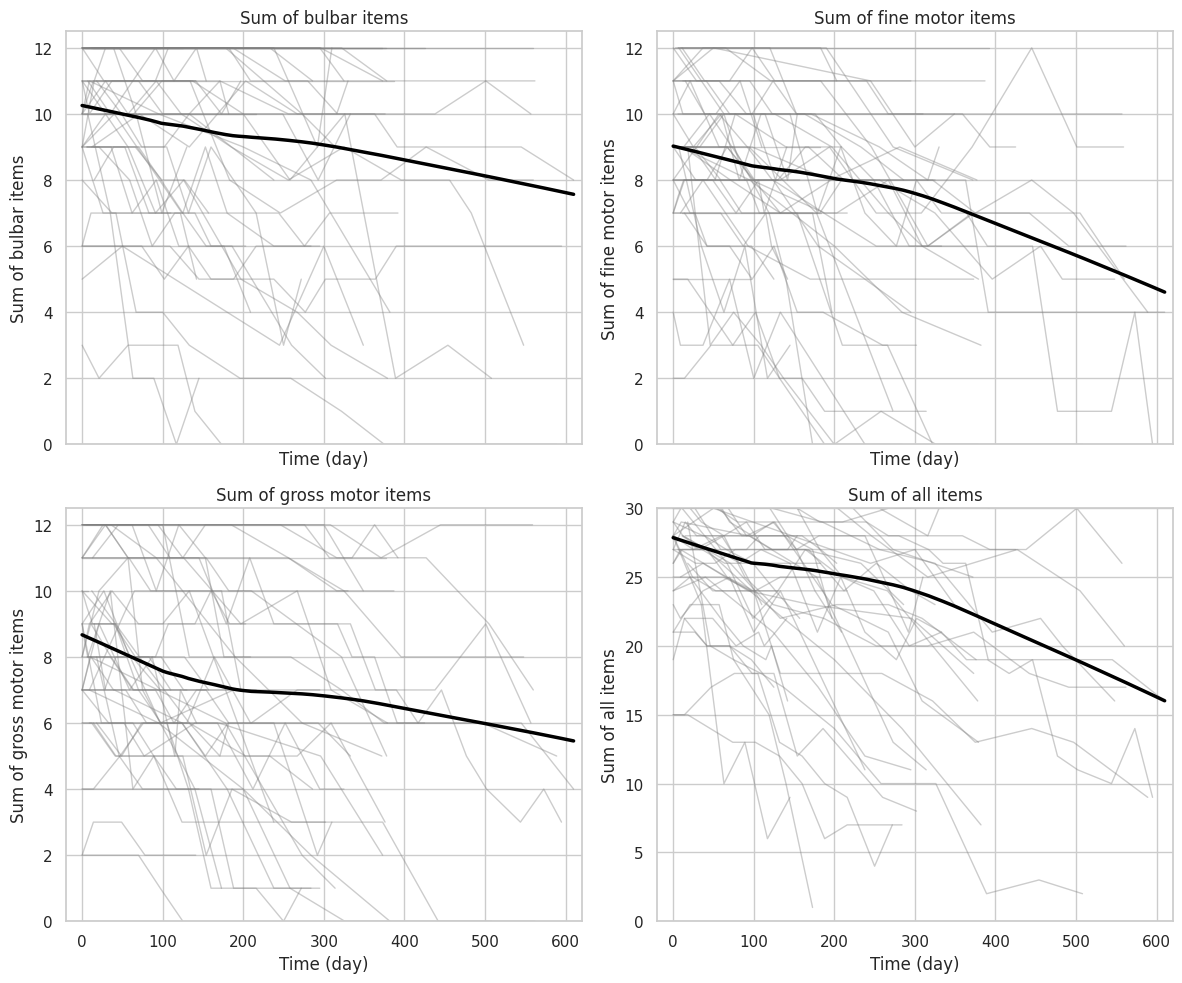

Generating Figure 2: Scatter plots between difference of current/future bulbar score and current lumbar score...


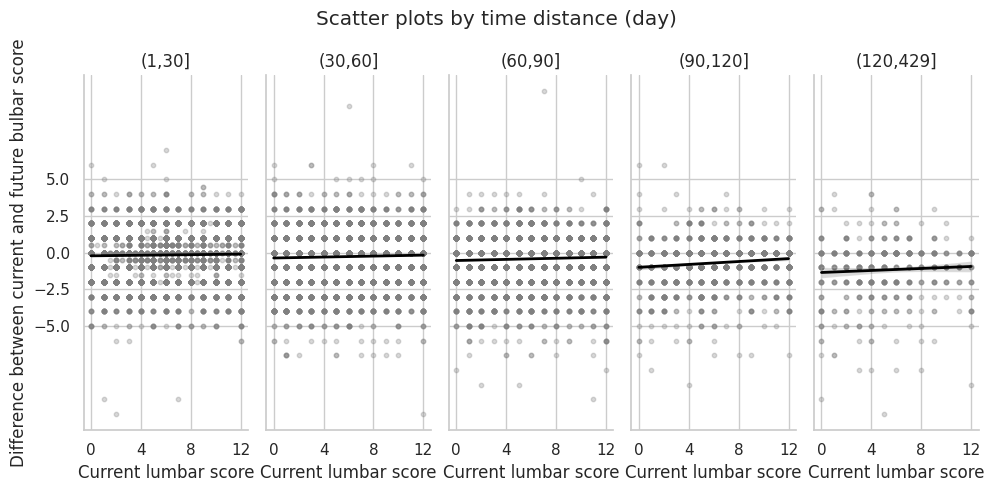

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

# Assuming 'datasets' dictionary is already populated from your load_data function
alsfrs_raw = datasets['alsfrs']

# ==========================================
# PART 2: DATA CLEANING & PREPARATION
# ==========================================
print("Cleaning and preparing ALSFRS data...")

# Filter out rows where occasion times (ALSFRS_Delta) are not known [cite: 374]
df = alsfrs_raw.dropna(subset=['subject_id', 'ALSFRS_Delta']).copy()
df = df[df['ALSFRS_Delta'] >= 0] # Keep only baseline and post-baseline visits

# Standardize column names based on standard PRO-ACT formatting. 
# You may need to adjust these string keys depending on the exact column names in your CSV.
q_cols = {
    'q1': 'Q1_Speech',
    'q2': 'Q2_Salivation',
    'q3': 'Q3_Swallowing',
    'q4': 'Q4_Handwriting',
    'q5a': 'Q5a_Cutting_without_Gastrostomy',
    'q5b': 'Q5b_Cutting_with_Gastrostomy',
    'q6': 'Q6_Dressing_and_Hygiene',
    'q7': 'Q7_Turning_in_Bed',
    'q8': 'Q8_Walking',
    'q9': 'Q9_Climbing_Stairs'
}

# The authors merged items 5a and 5b into item 5. If both were available, the maximum value was taken.
if q_cols['q5a'] in df.columns and q_cols['q5b'] in df.columns:
    df['Q5_Merged'] = df[[q_cols['q5a'], q_cols['q5b']]].max(axis=1)
else:
    # Fallback if the merge is already done or columns are named differently
    df['Q5_Merged'] = df.get('Q5_Cutting', np.nan)

# Group the items into three neurological categories [cite: 438]
df['Bulbar_Score'] = df[q_cols['q1']] + df[q_cols['q2']] + df[q_cols['q3']]
df['FineMotor_Score'] = df[q_cols['q4']] + df['Q5_Merged'] + df[q_cols['q6']]
df['GrossMotor_Score'] = df[q_cols['q7']] + df[q_cols['q8']] + df[q_cols['q9']]

# Sum of all 9 items
df['Total_9_Item_Score'] = df['Bulbar_Score'] + df['FineMotor_Score'] + df['GrossMotor_Score']

# Drop rows where our calculated scores are NaN to ensure clean plotting
df_clean = df.dropna(subset=['Bulbar_Score', 'FineMotor_Score', 'GrossMotor_Score', 'Total_9_Item_Score']).copy()


# ==========================================
# PART 3: REPRODUCING FIGURE 1
# ==========================================
print("Generating Figure 1: Profile plots for 50 randomly selected individuals...")

# Select 50 random subjects [cite: 425]
np.random.seed(42) # For reproducibility 
random_subjects = np.random.choice(df_clean['subject_id'].unique(), size=50, replace=False)
df_fig1 = df_clean[df_clean['subject_id'].isin(random_subjects)]

fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True)
axes = axes.flatten()

plot_configs = [
    {'y_col': 'Bulbar_Score', 'title': 'Sum of bulbar items', 'ylim': (0, 12.5)},
    {'y_col': 'FineMotor_Score', 'title': 'Sum of fine motor items', 'ylim': (0, 12.5)},
    {'y_col': 'GrossMotor_Score', 'title': 'Sum of gross motor items', 'ylim': (0, 12.5)},
    {'y_col': 'Total_9_Item_Score', 'title': 'Sum of all items', 'ylim': (0, 30)} # Adjusted ylim based on visual inspection of the paper's axis [cite: 414, 415]
]

for idx, config in enumerate(plot_configs):
    ax = axes[idx]
    
    # Plot individual thin grey lines
    for subject in random_subjects:
        subject_data = df_fig1[df_fig1['subject_id'] == subject].sort_values('ALSFRS_Delta')
        ax.plot(subject_data['ALSFRS_Delta'], subject_data[config['y_col']], 
                color='grey', alpha=0.4, linewidth=1)
    
    # Plot LOESS curve (thick black line) [cite: 427]
    sns.regplot(data=df_fig1, x='ALSFRS_Delta', y=config['y_col'], 
                scatter=False, lowess=True, color='black', 
                line_kws={'linewidth': 2.5}, ax=ax)
    
    ax.set_title(config['title'])
    ax.set_xlabel('Time (day)')
    ax.set_ylabel(config['title'])
    ax.set_xlim(-20, 620)
    ax.set_ylim(config['ylim'])
    
plt.tight_layout()
plt.show()


# ==========================================
# PART 4: REPRODUCING FIGURE 2
# ==========================================
print("Generating Figure 2: Scatter plots between difference of current/future bulbar score and current lumbar score...")

# To look at current vs future, we need to sort and shift by subject
df_fig2 = df_clean.sort_values(['subject_id', 'ALSFRS_Delta']).copy()

# Create 'Future' columns by shifting data grouped by subject_id
df_fig2['Next_Delta'] = df_fig2.groupby('subject_id')['ALSFRS_Delta'].shift(-1)
df_fig2['Next_Bulbar'] = df_fig2.groupby('subject_id')['Bulbar_Score'].shift(-1)

# Calculate Time Distance and Score Differences
df_fig2['Time_Distance'] = df_fig2['Next_Delta'] - df_fig2['ALSFRS_Delta']

# The paper plots "Difference between current and future bulbar score" [cite: 447]
# Depending on convention, this is usually (Future - Current) or (Current - Future).
# We'll use (Next_Bulbar - Bulbar_Score) as ALSFRS generally decreases over time.
df_fig2['Bulbar_Diff'] = df_fig2['Next_Bulbar'] - df_fig2['Bulbar_Score']

# Drop the last visit for each patient (since it has no 'future' visit)
df_fig2 = df_fig2.dropna(subset=['Time_Distance', 'Bulbar_Diff'])

# Bin the time distances as specified in the paper: (1,30], (30,60], (60,90], (90,120], (120,429] [cite: 450, 451, 452, 453, 454]
bins = [1, 30, 60, 90, 120, 429]
labels = ['(1,30]', '(30,60]', '(60,90]', '(90,120]', '(120,429]']
df_fig2['Time_Bin'] = pd.cut(df_fig2['Time_Distance'], bins=bins, labels=labels)

# Filter out rows that fall outside these bins
df_fig2_binned = df_fig2.dropna(subset=['Time_Bin'])

# Using seaborn's lmplot to create the faceted scatter plots with linear regression lines
g = sns.lmplot(
    data=df_fig2_binned,
    x='GrossMotor_Score', # The paper refers to lumbar score, which represents gross motor function 
    y='Bulbar_Diff',
    col='Time_Bin',
    col_order=labels,
    scatter_kws={'color': 'grey', 'alpha': 0.3, 's': 10},
    line_kws={'color': 'black', 'linewidth': 2},
    height=5, aspect=0.4
)

# Formatting axes
g.set_axis_labels('Current lumbar score', 'Difference between current and future bulbar score')
g.set(xticks=[0, 4, 8, 12], yticks=[-5.0, -2.5, 0.0, 2.5, 5.0])
g.set_titles("{col_name}")

plt.subplots_adjust(top=0.85)
g.fig.suptitle('Scatter plots by time distance (day)')
plt.show()

Generating Figure 1: Profile plots for 50 randomly selected individuals...


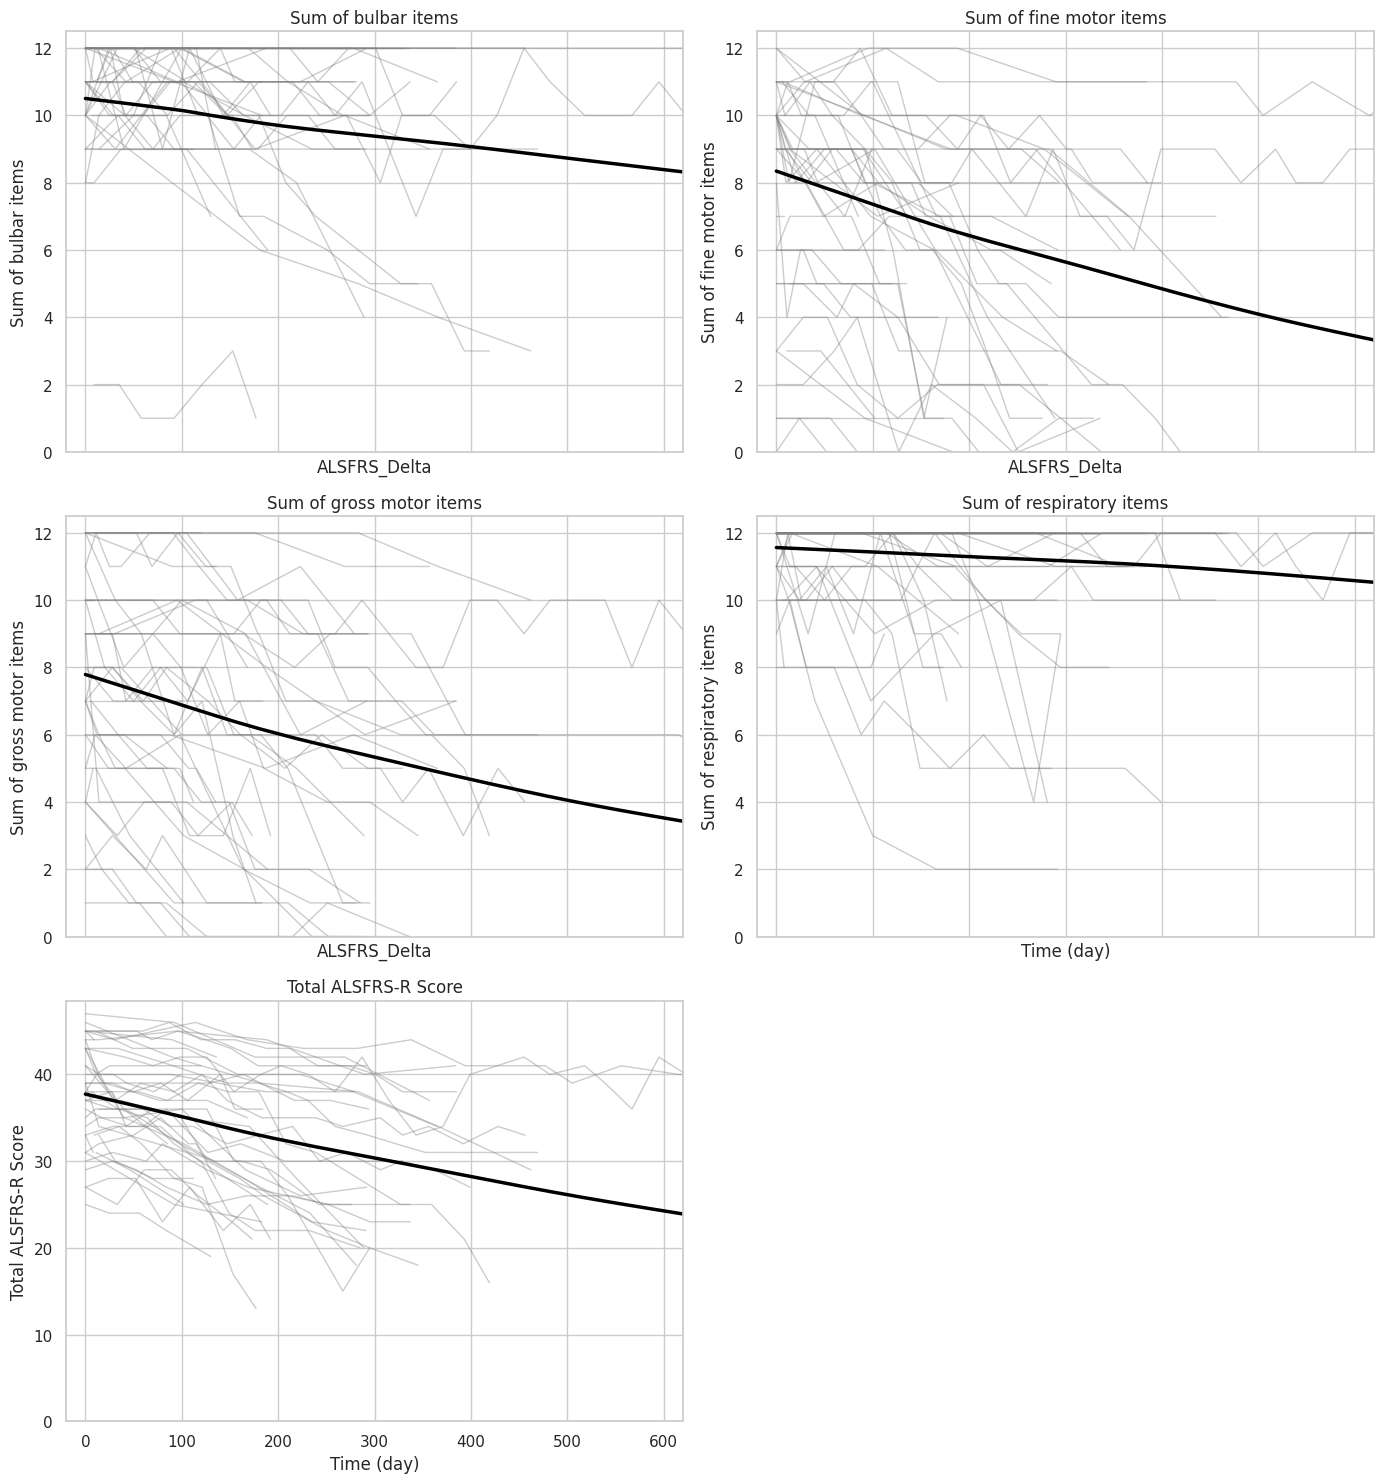

In [7]:
# ==========================================
# PART 3: REPRODUCING FIGURE 1 (Corrected LOESS)
# ==========================================
print("Generating Figure 1: Profile plots for 50 randomly selected individuals...")

# Select 50 random subjects for the background lines
np.random.seed(42)  
random_subjects = np.random.choice(df_clean['subject_id'].unique(), size=50, replace=False)
df_fig1 = df_clean[df_clean['subject_id'].isin(random_subjects)]

fig, axes = plt.subplots(3, 2, figsize=(14, 15), sharex=True)
axes = axes.flatten()

plot_configs = [
    {'y_col': 'Bulbar_Score', 'title': 'Sum of bulbar items', 'ylim': (0, 12.5)},
    {'y_col': 'FineMotor_Score', 'title': 'Sum of fine motor items', 'ylim': (0, 12.5)},
    {'y_col': 'GrossMotor_Score', 'title': 'Sum of gross motor items', 'ylim': (0, 12.5)},
    {'y_col': 'Respiratory_Score', 'title': 'Sum of respiratory items', 'ylim': (0, 12.5)},
    {'y_col': 'Total_ALSFRSR_Score', 'title': 'Total ALSFRS-R Score', 'ylim': (0, 48.5)}
]

for idx, config in enumerate(plot_configs):
    ax = axes[idx]
    
    # 1. Plot individual thin grey lines ONLY for the 50 random subjects
    for subject in random_subjects:
        subject_data = df_fig1[df_fig1['subject_id'] == subject].sort_values('ALSFRS_Delta')
        ax.plot(subject_data['ALSFRS_Delta'], subject_data[config['y_col']], 
                color='grey', alpha=0.4, linewidth=1)
    
    # 2. Plot LOESS curve using the ENTIRE dataset (df_clean) to get the true population trend
    # Note: Depending on your CPU, calculating LOESS on 50,000+ rows might take 10-30 seconds.
    sns.regplot(data=df_clean, x='ALSFRS_Delta', y=config['y_col'], 
                scatter=False, lowess=True, color='black', 
                line_kws={'linewidth': 2.5}, ax=ax)
    
    ax.set_title(config['title'])
    ax.set_ylabel(config['title'])
    
    if idx >= 3:
        ax.set_xlabel('Time (day)')
        
    ax.set_xlim(-20, 620)
    ax.set_ylim(config['ylim'])

axes[5].set_visible(False)

plt.tight_layout()
plt.show()

Checking longitudinal alignment within a +/- 14 day window...



      Dataset  Total ALSFRS Visits  Matched Records  Alignment Rate (%)
         LABS                50581            34334                67.9
       VITALS                50581            29769                58.9
          SVC                50581            20751                41.0
          FVC                50581            15557                30.8
       MUSCLE                50581            10819                21.4
     HANDGRIP                50581             6708                13.3
NEUROFILAMENT                50581             3721                 7.4


/tmp/ipykernel_50641/657205255.py:105: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


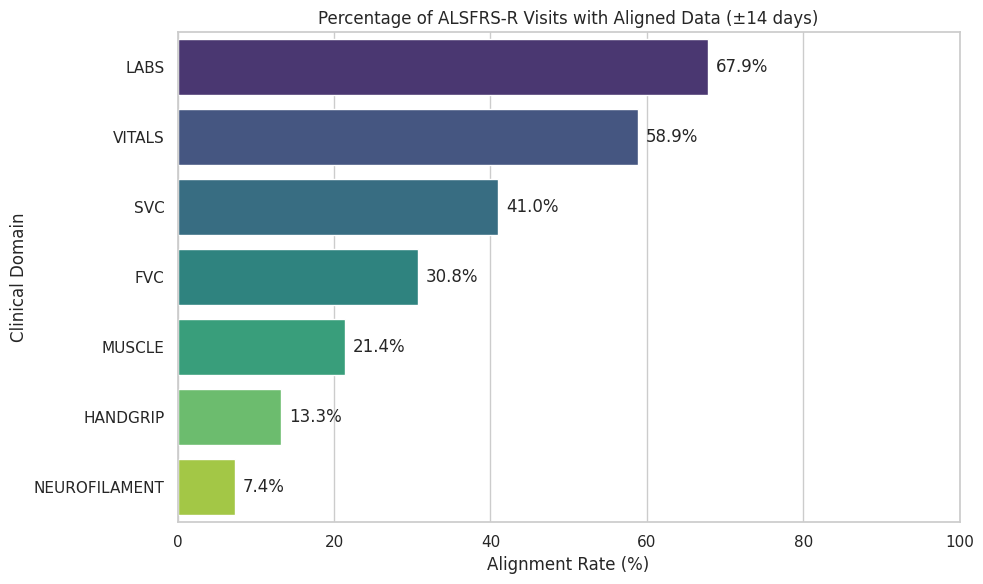

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming df_clean is the dataframe we generated in the previous step 
# that contains the calculated ALSFRS-R scores and no missing Subject IDs.

# ==========================================
# ALIGNMENT CHECKER CONFIGURATION
# ==========================================
# Set a clinical visit tolerance window (e.g., +/- 14 days)
TOLERANCE_DAYS = 14

print(f"Checking longitudinal alignment within a +/- {TOLERANCE_DAYS} day window...\n")

# We only need the subject ID and the time of the ALSFRS assessment
alsfrs_base = df_clean[['subject_id', 'ALSFRS_Delta']].copy()

# merge_asof requires the dataframes to be sorted by the key (Delta)
alsfrs_base = alsfrs_base.sort_values('ALSFRS_Delta')

# List of longitudinal datasets we want to check
longitudinal_keys = [
    'fvc', 'svc', 'vitals', 'handgrip', 'muscle', 'labs', 'neurofilament'
]

results = []

# Force baseline types just to be absolutely sure
alsfrs_base['subject_id'] = alsfrs_base['subject_id'].astype('int64')
alsfrs_base['ALSFRS_Delta'] = alsfrs_base['ALSFRS_Delta'].astype('float64')

results = []

for key in longitudinal_keys:
    df_target = datasets.get(key)
    
    # Skip if dataset wasn't loaded
    if df_target is None or df_target.empty:
        continue
        
    # Dynamically find the subject_id and Delta columns in the target dataset
    cols = df_target.columns
    try:
        subj_col = [c for c in cols if 'subject' in c.lower()][0]
        delta_col = [c for c in cols if 'delta' in c.lower()][0]
    except IndexError:
        print(f"Skipping {key}: Could not find Subject or Delta column.")
        continue

    # Clean target dataframe: keep only ID and Delta
    df_t = df_target[[subj_col, delta_col]].copy()
    
    # Standardize column names for the merge
    df_t = df_t.rename(columns={subj_col: 'subject_id', delta_col: 'Target_Delta'})
    
    # Drop missing values BEFORE casting types
    df_t = df_t.dropna(subset=['subject_id', 'Target_Delta'])
    
    # STRICT TYPE CASTING to match alsfrs_base
    df_t['subject_id'] = df_t['subject_id'].astype('int64')
    df_t['Target_Delta'] = pd.to_numeric(df_t['Target_Delta'], errors='coerce').astype('float64')
    
    # Drop any new NaNs created by coercion and sort (required for merge_asof)
    df_t = df_t.dropna().sort_values('Target_Delta')
    
    # We only care IF there's at least one record in the window, so we drop exact duplicates
    df_t = df_t.drop_duplicates(subset=['subject_id', 'Target_Delta'])

    # ---------------------------------------------------------
    # Perform the fuzzy time merge
    # ---------------------------------------------------------
    merged = pd.merge_asof(
        alsfrs_base, 
        df_t,
        left_on='ALSFRS_Delta',
        right_on='Target_Delta',
        by='subject_id',
        direction='nearest',
        tolerance=TOLERANCE_DAYS
    )

    # Calculate alignment statistics
    total_alsfrs_obs = len(alsfrs_base)
    matched_obs = merged['Target_Delta'].notna().sum()
    match_rate = (matched_obs / total_alsfrs_obs) * 100

    results.append({
        'Dataset': key.upper(),
        'Total ALSFRS Visits': total_alsfrs_obs,
        f'Matched Records': matched_obs,
        'Alignment Rate (%)': match_rate
    })
# ==========================================
# DISPLAY RESULTS
# ==========================================
alignment_df = pd.DataFrame(results).sort_values('Alignment Rate (%)', ascending=False)

# Print tabular results
print(alignment_df.to_string(index=False, float_format="%.1f"))

# Plot the alignment rates
plt.figure(figsize=(10, 6))
sns.barplot(
    data=alignment_df, 
    x='Alignment Rate (%)', 
    y='Dataset', 
    palette='viridis'
)
plt.title(f'Percentage of ALSFRS-R Visits with Aligned Data (±{TOLERANCE_DAYS} days)')
plt.xlabel('Alignment Rate (%)')
plt.ylabel('Clinical Domain')
plt.xlim(0, 100)

# Add text labels to the bars
for index, value in enumerate(alignment_df['Alignment Rate (%)']):
    plt.text(value + 1, index, f'{value:.1f}%', va='center')

plt.tight_layout()
plt.show()

Generating trajectory plots with unit-corrected data...


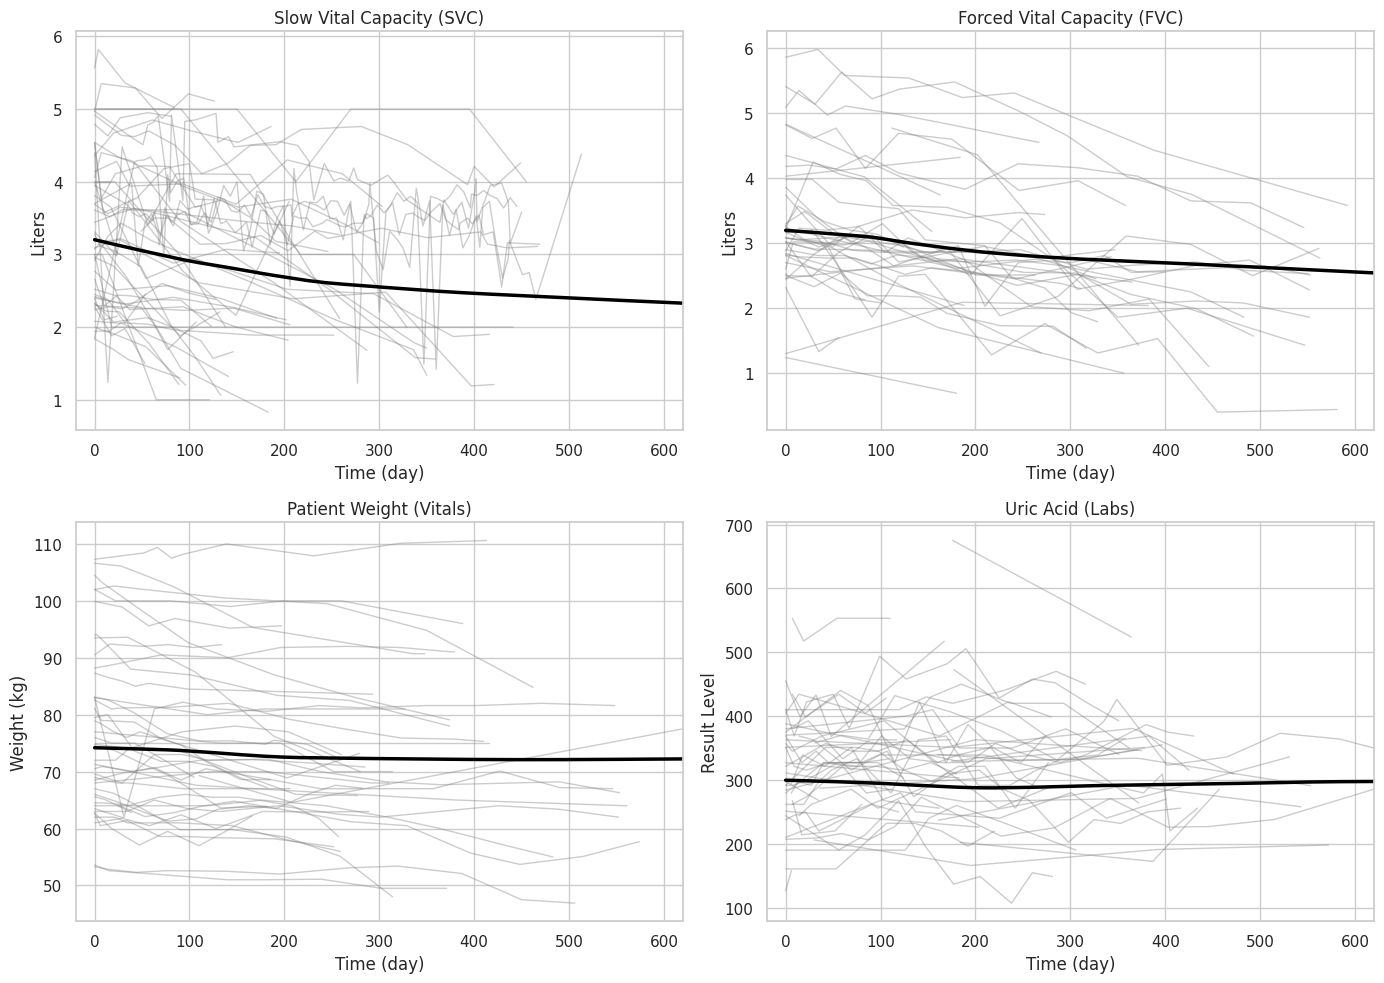

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def plot_trajectory(df, subj_col, time_col, val_col, title, ylabel, ax):
    """Helper function to plot 50 random patients and a population LOESS curve."""
    df_clean = df.copy()
    df_clean[time_col] = pd.to_numeric(df_clean[time_col], errors='coerce')
    df_clean[val_col] = pd.to_numeric(df_clean[val_col], errors='coerce')
    df_clean = df_clean.dropna(subset=[subj_col, time_col, val_col])
    
    # Filter to only include post-baseline visits (Delta >= 0)
    df_clean = df_clean[df_clean[time_col] >= 0]
    
    if df_clean.empty:
        ax.set_title(f"{title} (No Data)")
        return

    np.random.seed(42)
    unique_subjects = df_clean[subj_col].unique()
    num_samples = min(50, len(unique_subjects))
    random_subjects = np.random.choice(unique_subjects, size=num_samples, replace=False)
    
    df_sample = df_clean[df_clean[subj_col].isin(random_subjects)]
    
    # 1. Plot individual thin grey lines
    for subject in random_subjects:
        subj_data = df_sample[df_sample[subj_col] == subject].sort_values(time_col)
        ax.plot(subj_data[time_col], subj_data[val_col], color='grey', alpha=0.4, linewidth=1)
        
    # 2. Plot LOESS curve
    sns.regplot(
        data=df_clean, x=time_col, y=val_col, 
        scatter=False, lowess=True, color='black', 
        line_kws={'linewidth': 2.5}, ax=ax
    )
    
    ax.set_title(title)
    ax.set_xlabel('Time (day)')
    ax.set_ylabel(ylabel)
    ax.set_xlim(-20, 620)

# ==========================================
# GENERATE THE 2x2 PLOT GRID
# ==========================================
print("Generating trajectory plots with unit-corrected data...")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# 1. SVC Trajectory (Targeting Trial_1 specifically)
df_svc = datasets.get('svc')
if df_svc is not None:
    plot_trajectory(df_svc, 'subject_id', 'Slow_vital_Capacity_Delta', 'Subject_Liters_Trial_1', 
                    "Slow Vital Capacity (SVC)", "Liters", axes[0])

# 2. FVC Trajectory (Targeting Trial_1 specifically)
df_fvc = datasets.get('fvc')
if df_fvc is not None:
    plot_trajectory(df_fvc, 'subject_id', 'Forced_Vital_Capacity_Delta', 'Subject_Liters_Trial_1', 
                    "Forced Vital Capacity (FVC)", "Liters", axes[1])

# 3. Vitals Trajectory (Standardizing Lbs to Kg)
df_vit = datasets.get('vitals').copy()
if df_vit is not None:
    # Convert pounds to kilograms where necessary
    is_lbs = df_vit['Weight_Units'].astype(str).str.lower().str.contains('lb', na=False)
    df_vit.loc[is_lbs, 'Weight'] = df_vit.loc[is_lbs, 'Weight'] * 0.453592
    
    plot_trajectory(df_vit, 'subject_id', 'Vital_Signs_Delta', 'Weight', 
                    "Patient Weight (Vitals)", "Weight (kg)", axes[2])

# 4. Labs Trajectory (Uric Acid)
df_labs = datasets.get('labs')
if df_labs is not None:
    # Filter the long-format labs table for just Uric Acid
    df_uric = df_labs[df_labs['Test_Name'].astype(str).str.contains('Uric Acid', case=False, na=False)]
    plot_trajectory(df_uric, 'subject_id', 'Laboratory_Delta', 'Test_Result', 
                    "Uric Acid (Labs)", "Result Level", axes[3])

plt.tight_layout()
plt.show()

Generating trajectory plots for Respiratory Rate, CK, Creatinine, and Albumin...


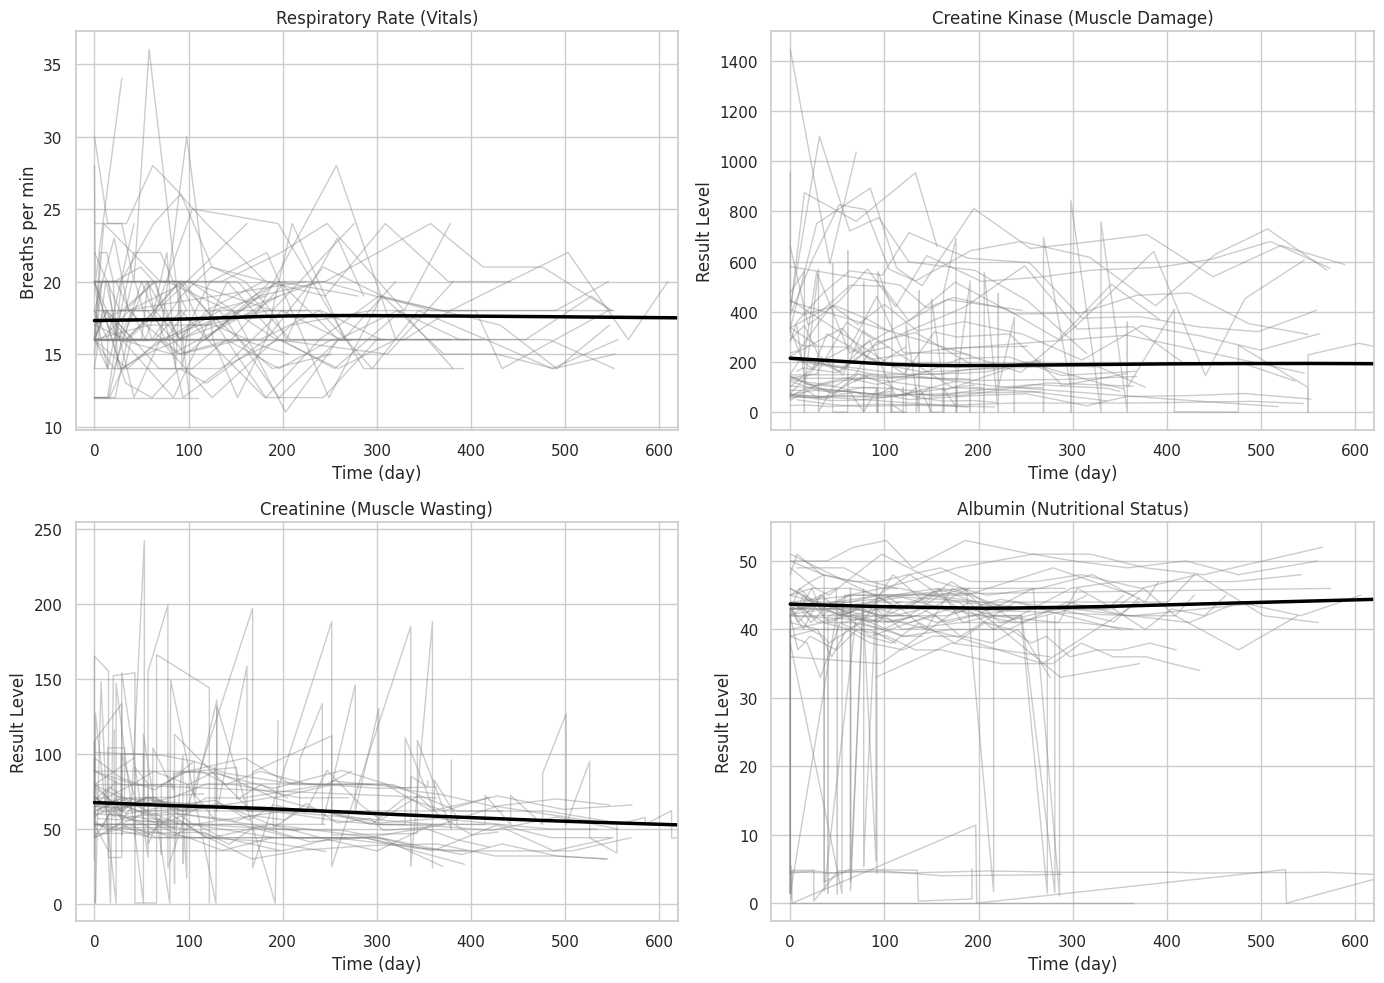

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def plot_trajectory(df, subj_col, time_col, val_col, title, ylabel, ax):
    """Helper function to plot 50 random patients and a population LOESS curve."""
    df_clean = df.copy()
    # Force numeric conversion (turns strings like '< 0.5' into NaN safely)
    df_clean[time_col] = pd.to_numeric(df_clean[time_col], errors='coerce')
    df_clean[val_col] = pd.to_numeric(df_clean[val_col], errors='coerce')
    df_clean = df_clean.dropna(subset=[subj_col, time_col, val_col])
    
    # Filter to only include post-baseline visits (Delta >= 0)
    df_clean = df_clean[df_clean[time_col] >= 0]
    
    if df_clean.empty:
        ax.set_title(f"{title} (No Data)")
        return

    np.random.seed(42)
    unique_subjects = df_clean[subj_col].unique()
    num_samples = min(50, len(unique_subjects))
    random_subjects = np.random.choice(unique_subjects, size=num_samples, replace=False)
    
    df_sample = df_clean[df_clean[subj_col].isin(random_subjects)]
    
    # 1. Plot individual thin grey lines
    for subject in random_subjects:
        subj_data = df_sample[df_sample[subj_col] == subject].sort_values(time_col)
        ax.plot(subj_data[time_col], subj_data[val_col], color='grey', alpha=0.4, linewidth=1)
        
    # 2. Plot LOESS curve
    sns.regplot(
        data=df_clean, x=time_col, y=val_col, 
        scatter=False, lowess=True, color='black', 
        line_kws={'linewidth': 2.5}, ax=ax
    )
    
    ax.set_title(title)
    ax.set_xlabel('Time (day)')
    ax.set_ylabel(ylabel)
    ax.set_xlim(-20, 620)

# ==========================================
# GENERATE THE 2x2 PLOT GRID
# ==========================================
print("Generating trajectory plots for Respiratory Rate, CK, Creatinine, and Albumin...")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# 1. Respiratory Rate (from Vitals)
df_vit = datasets.get('vitals')
if df_vit is not None:
    plot_trajectory(df_vit, 'subject_id', 'Vital_Signs_Delta', 'Respiratory_Rate', 
                    "Respiratory Rate (Vitals)", "Breaths per min", axes[0])

# --- LABS EXTRACTION ---
df_labs = datasets.get('labs')
if df_labs is not None:
    # 2. Creatine Kinase (CK)
    # Extracts markers of active muscle damage
    df_ck = df_labs[df_labs['Test_Name'].astype(str).str.contains('Creatine Kinase', case=False, na=False)]
    plot_trajectory(df_ck, 'subject_id', 'Laboratory_Delta', 'Test_Result', 
                    "Creatine Kinase (Muscle Damage)", "Result Level", axes[1])

    # 3. Creatinine
    # Extracts markers of overall muscle mass / wasting
    df_creat = df_labs[df_labs['Test_Name'].astype(str).str.contains('Creatinine', case=False, na=False)]
    plot_trajectory(df_creat, 'subject_id', 'Laboratory_Delta', 'Test_Result', 
                    "Creatinine (Muscle Wasting)", "Result Level", axes[2])

    # 4. Albumin
    # Extracts markers of nutritional status / dehydration (Bulbar decline)
    # Using an exact match or strict contains to avoid 'Urine Microalbumin'
    df_alb = df_labs[df_labs['Test_Name'].astype(str).str.contains('Albumin', case=False, na=False)]
    plot_trajectory(df_alb, 'subject_id', 'Laboratory_Delta', 'Test_Result', 
                    "Albumin (Nutritional Status)", "Result Level", axes[3])

plt.tight_layout()
plt.show()

Aggregating and generating trajectory plots for Muscle, Handgrip, and Neurofilament...


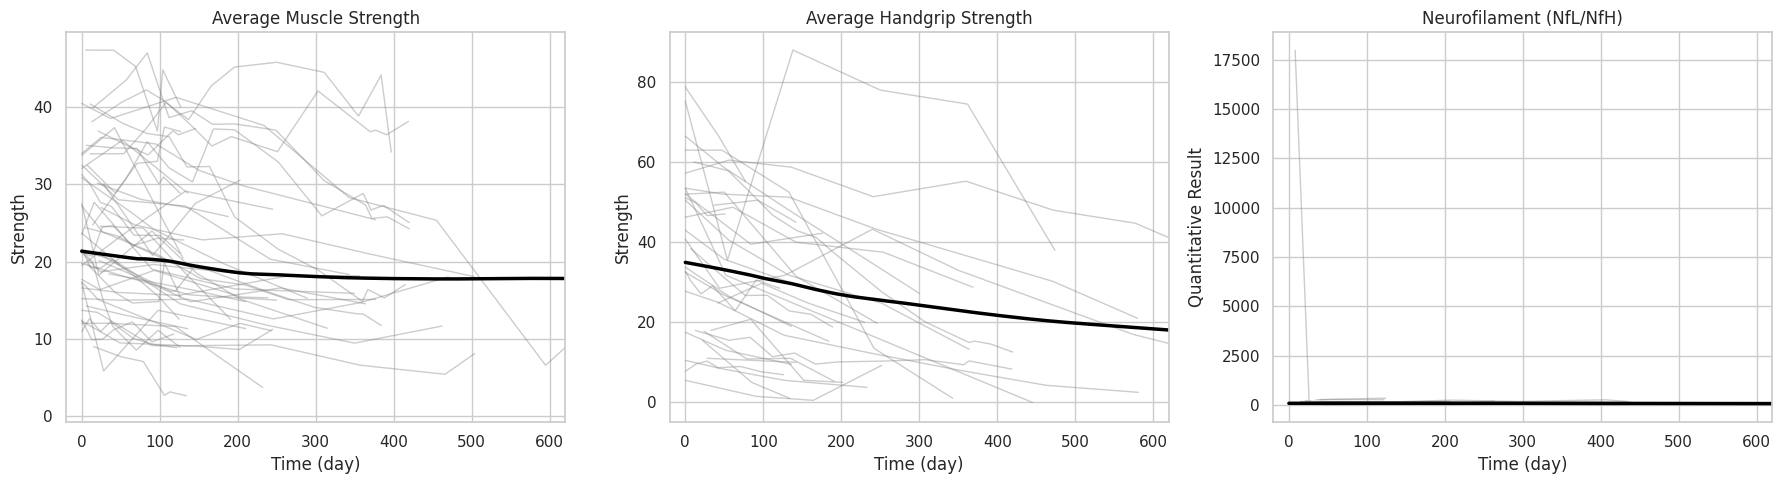

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def plot_trajectory(df, subj_col, time_col, val_col, title, ylabel, ax):
    """Helper function to plot 50 random patients and a population LOESS curve."""
    df_clean = df.copy()
    df_clean[time_col] = pd.to_numeric(df_clean[time_col], errors='coerce')
    df_clean[val_col] = pd.to_numeric(df_clean[val_col], errors='coerce')
    df_clean = df_clean.dropna(subset=[subj_col, time_col, val_col])
    
    # Filter to only include post-baseline visits
    df_clean = df_clean[df_clean[time_col] >= 0]
    
    if df_clean.empty:
        ax.set_title(f"{title} (No Data)")
        return

    np.random.seed(42)
    unique_subjects = df_clean[subj_col].unique()
    num_samples = min(50, len(unique_subjects))
    random_subjects = np.random.choice(unique_subjects, size=num_samples, replace=False)
    
    df_sample = df_clean[df_clean[subj_col].isin(random_subjects)]
    
    # 1. Plot individual thin grey lines
    for subject in random_subjects:
        subj_data = df_sample[df_sample[subj_col] == subject].sort_values(time_col)
        ax.plot(subj_data[time_col], subj_data[val_col], color='grey', alpha=0.4, linewidth=1)
        
    # 2. Plot LOESS curve
    sns.regplot(
        data=df_clean, x=time_col, y=val_col, 
        scatter=False, lowess=True, color='black', 
        line_kws={'linewidth': 2.5}, ax=ax
    )
    
    ax.set_title(title)
    ax.set_xlabel('Time (day)')
    ax.set_ylabel(ylabel)
    ax.set_xlim(-20, 620)


# ==========================================
# GENERATE THE 1x3 PLOT GRID
# ==========================================
print("Aggregating and generating trajectory plots for Muscle, Handgrip, and Neurofilament...")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes = axes.flatten()

# 1. Muscle Strength (Average across all tested muscles per visit)
df_muscle = datasets.get('muscle')
if df_muscle is not None and not df_muscle.empty:
    subj_col = [c for c in df_muscle.columns if 'subject' in c.lower()][0]
    delta_col = [c for c in df_muscle.columns if 'delta' in c.lower()][0]
    val_col = [c for c in df_muscle.columns if 'result' in c.lower()][0]
    
    df_m_clean = df_muscle.copy()
    df_m_clean[val_col] = pd.to_numeric(df_m_clean[val_col], errors='coerce')
    # Group by patient and visit day to get the mean muscle strength for that visit
    df_m_avg = df_m_clean.groupby([subj_col, delta_col])[val_col].mean().reset_index()
    
    plot_trajectory(df_m_avg, subj_col, delta_col, val_col, 
                    "Average Muscle Strength", "Strength", axes[0])

# 2. Handgrip Strength (Average of Left and Right hands per visit)
df_hand = datasets.get('handgrip')
if df_hand is not None and not df_hand.empty:
    subj_col = [c for c in df_hand.columns if 'subject' in c.lower()][0]
    delta_col = [c for c in df_hand.columns if 'delta' in c.lower()][0]
    val_col = [c for c in df_hand.columns if 'result' in c.lower()][0]
    
    df_h_clean = df_hand.copy()
    df_h_clean[val_col] = pd.to_numeric(df_h_clean[val_col], errors='coerce')
    # Group by patient and visit day to get the mean handgrip strength
    df_h_avg = df_h_clean.groupby([subj_col, delta_col])[val_col].mean().reset_index()
    
    plot_trajectory(df_h_avg, subj_col, delta_col, val_col, 
                    "Average Handgrip Strength", "Strength", axes[1])

# 3. Neurofilament (NfL / NfH)
df_nf = datasets.get('neurofilament')
if df_nf is not None and not df_nf.empty:
    subj_col = [c for c in df_nf.columns if 'subject' in c.lower()][0]
    delta_col = [c for c in df_nf.columns if 'delta' in c.lower()][0]
    val_col = [c for c in df_nf.columns if 'result' in c.lower()][0]
    
    # Neurofilament doesn't need to be averaged, we can just plot the raw quantitative results
    plot_trajectory(df_nf, subj_col, delta_col, val_col, 
                    "Neurofilament (NfL/NfH)", "Quantitative Result", axes[2])

plt.tight_layout()
plt.show()

Extracting baseline covariates for the ALSFRS-R patient cohort...
Total Unique Patients in ALSFRS-R subset: 5711
Generating covariate summary dashboard...


/tmp/ipykernel_50641/1417761742.py:85: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_cohort, x='Sex', ax=axes[2], palette='pastel')
/tmp/ipykernel_50641/1417761742.py:89: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_cohort, x='Site_of_Onset', ax=axes[3], palette='Set2')
/tmp/ipykernel_50641/1417761742.py:94: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_cohort, x='Study_Arm', ax=axes[4], palette='Set1')
/tmp/ipykernel_50641/1417761742.py:99: FutureWarning: 

Passing `palette` without assigning `hue` is deprecat

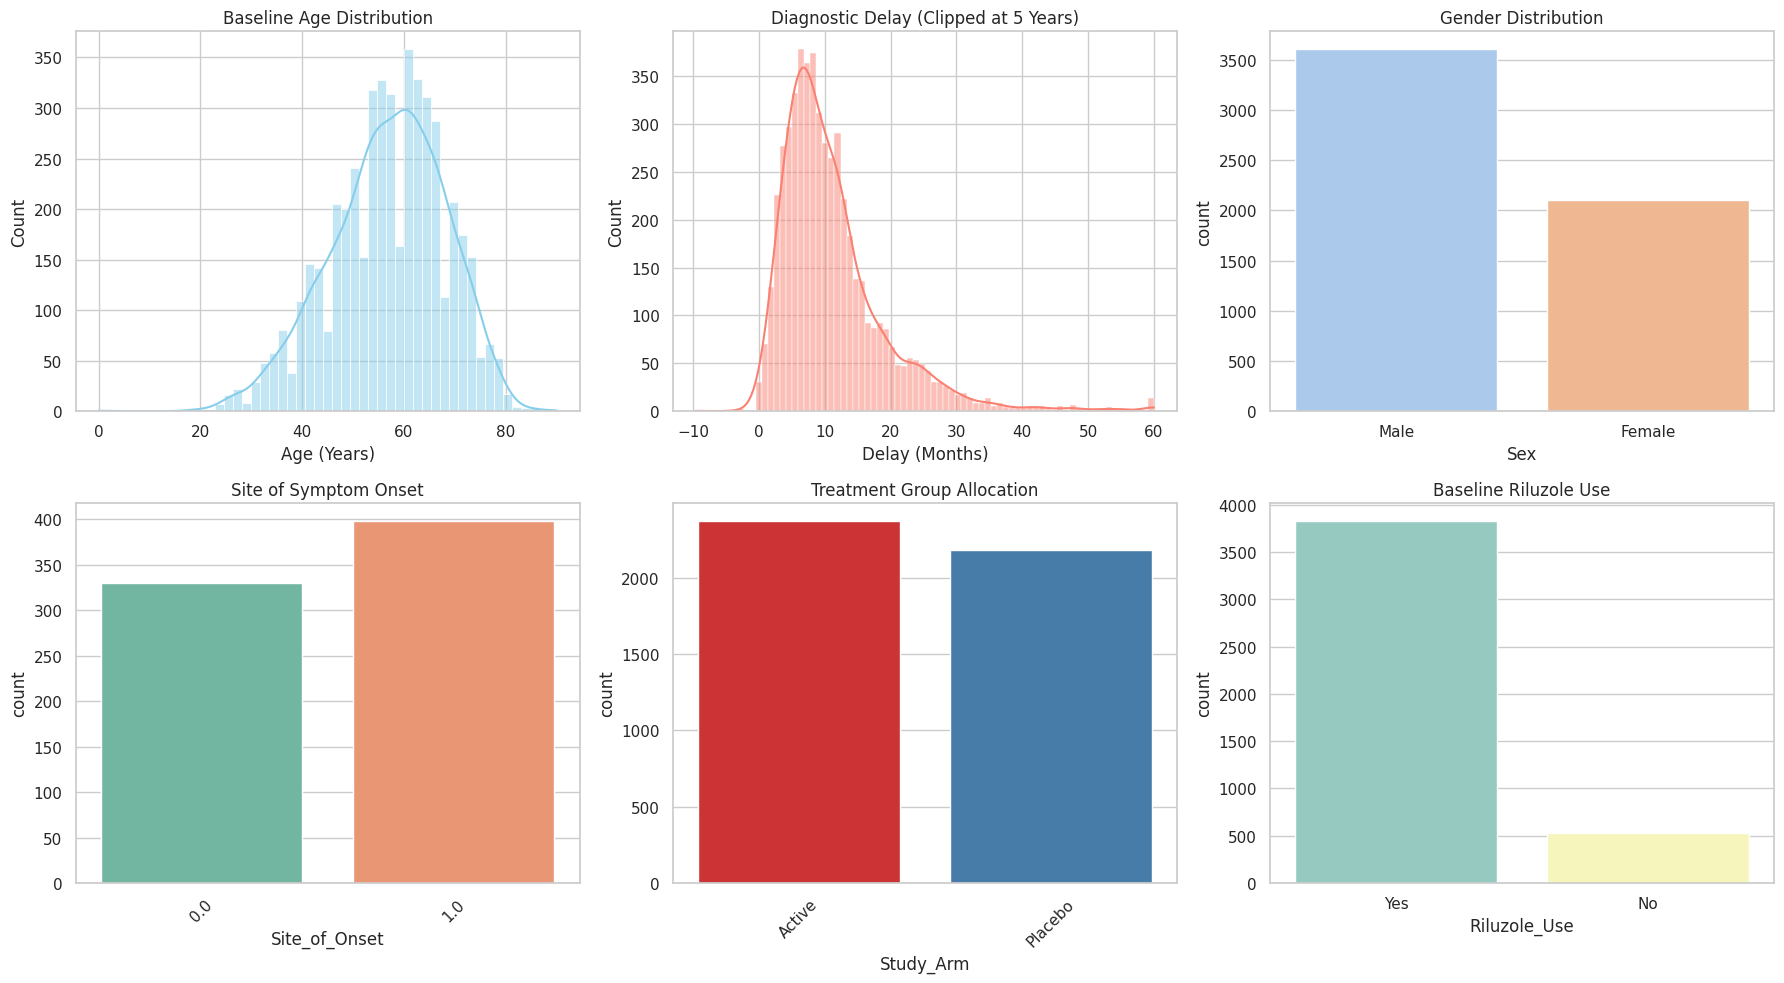


=== Cohort Statistical Summary ===
           Age  Diagnostic_Delay_Months
count  4846.00                  5305.00
mean     56.86                    11.22
std      11.27                     8.50
min       0.00                    -9.59
25%      50.00                     5.91
50%      58.00                     9.13
75%      65.00                    13.99
max      90.00                   100.95


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Extracting baseline covariates for the ALSFRS-R patient cohort...")

# 1. Get the unique patients from your cleaned ALSFRS-R subset
df_cohort = pd.DataFrame({'subject_id': df_clean['subject_id'].unique()})
print(f"Total Unique Patients in ALSFRS-R subset: {len(df_cohort)}")

# 2. Extract Demographics (Age, Sex)
df_demo = datasets.get('demographics')
if df_demo is not None:
    age_col = [c for c in df_demo.columns if 'age' in c.lower()][0]
    sex_col = [c for c in df_demo.columns if 'sex' in c.lower() or 'gender' in c.lower()][0]
    
    demo_subset = df_demo[['subject_id', age_col, sex_col]].drop_duplicates(subset=['subject_id'])
    df_cohort = df_cohort.merge(demo_subset, on='subject_id', how='left')
    df_cohort.rename(columns={age_col: 'Age', sex_col: 'Sex'}, inplace=True)

# 3. Extract ALS History (Site of Onset, Diagnostic Delay)
df_hist = datasets.get('history')
if df_hist is not None:
    # Safely identify columns
    onset_site_col = [c for c in df_hist.columns if 'site' in c.lower()][0]
    onset_delta_col = [c for c in df_hist.columns if 'onset_delta' in c.lower() or ('onset' in c.lower() and 'delta' in c.lower())][0]
    diag_delta_col = [c for c in df_hist.columns if 'diagnosis_delta' in c.lower() or ('diag' in c.lower() and 'delta' in c.lower())][0]
    
    hist_subset = df_hist[['subject_id', onset_site_col, onset_delta_col, diag_delta_col]].drop_duplicates(subset=['subject_id'])
    df_cohort = df_cohort.merge(hist_subset, on='subject_id', how='left')
    df_cohort.rename(columns={onset_site_col: 'Site_of_Onset'}, inplace=True)
    
    # Calculate Diagnostic Delay in Months
    # Note: Onset and Diagnosis Deltas are usually negative (days before trial began).
    # Time from onset to diagnosis = Diagnosis Delta - Onset Delta
    df_cohort['Diagnostic_Delay_Months'] = (df_cohort[diag_delta_col] - df_cohort[onset_delta_col]) / 30.44

# 4. Extract Treatment Arm
df_treat = datasets.get('treatment')
if df_treat is not None:
    arm_col = [c for c in df_treat.columns if 'arm' in c.lower() or 'group' in c.lower() and 'delta' not in c.lower()][0]
    treat_subset = df_treat[['subject_id', arm_col]].drop_duplicates(subset=['subject_id'])
    df_cohort = df_cohort.merge(treat_subset, on='subject_id', how='left')
    df_cohort.rename(columns={arm_col: 'Study_Arm'}, inplace=True)

# 5. Extract Riluzole Use
df_ril = datasets.get('riluzole')
if df_ril is not None:
    ril_col = [c for c in df_ril.columns if 'use' in c.lower() or 'riluzole' in c.lower() and 'delta' not in c.lower()][0]
    ril_subset = df_ril[['subject_id', ril_col]].drop_duplicates(subset=['subject_id'])
    df_cohort = df_cohort.merge(ril_subset, on='subject_id', how='left')
    df_cohort.rename(columns={ril_col: 'Riluzole_Use'}, inplace=True)

# 6. Extract Familial vs Sporadic Proxy
df_fam = datasets.get('family')
if df_fam is not None:
    # If a patient has a record in the family history table reporting neurological diseases,
    # we flag them. Otherwise, we assume Sporadic/Unknown.
    df_cohort['Familial_ALS'] = df_cohort['subject_id'].isin(df_fam['subject_id']).map({True: 'Yes', False: 'No/Unknown'})

# ==========================================
# VISUALIZE THE COVARIATE DISTRIBUTIONS
# ==========================================
print("Generating covariate summary dashboard...")

# Set up the visualization grid
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
sns.set_theme(style="whitegrid")

# 1. Age Distribution
sns.histplot(data=df_cohort, x='Age', kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Baseline Age Distribution')
axes[0].set_xlabel('Age (Years)')

# 2. Diagnostic Delay Distribution
# Clip to 60 months to avoid extreme outliers skewing the visualization
df_cohort['Diagnostic_Delay_Plot'] = df_cohort['Diagnostic_Delay_Months'].clip(upper=60)
sns.histplot(data=df_cohort, x='Diagnostic_Delay_Plot', kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Diagnostic Delay (Clipped at 5 Years)')
axes[1].set_xlabel('Delay (Months)')

# 3. Gender / Sex
sns.countplot(data=df_cohort, x='Sex', ax=axes[2], palette='pastel')
axes[2].set_title('Gender Distribution')

# 4. Site of Onset
sns.countplot(data=df_cohort, x='Site_of_Onset', ax=axes[3], palette='Set2')
axes[3].set_title('Site of Symptom Onset')
axes[3].tick_params(axis='x', rotation=45)

# 5. Study Arm (Active vs Placebo)
sns.countplot(data=df_cohort, x='Study_Arm', ax=axes[4], palette='Set1')
axes[4].set_title('Treatment Group Allocation')
axes[4].tick_params(axis='x', rotation=45)

# 6. Riluzole Use
sns.countplot(data=df_cohort, x='Riluzole_Use', ax=axes[5], palette='Set3')
axes[5].set_title('Baseline Riluzole Use')

plt.tight_layout()
plt.show()

# Print a quick statistical summary
print("\n=== Cohort Statistical Summary ===")
print(df_cohort[['Age', 'Diagnostic_Delay_Months']].describe().round(2))

In [32]:
import pandas as pd
import numpy as np

print("Compiling Table 1: Baseline Characteristics for the ALSFRS-R Subset...")

# 1. Base cohort (Only patients with complete ALSFRS-R data)
df_cohort = pd.DataFrame({'subject_id': df_clean['subject_id'].unique()})
total_patients = len(df_cohort)

# 2. Extract Demographics
df_demo = datasets.get('demographics')
age_col = [c for c in df_demo.columns if 'age' in c.lower()][0]
sex_col = [c for c in df_demo.columns if 'sex' in c.lower() or 'gender' in c.lower()][0]
df_cohort = df_cohort.merge(df_demo[['subject_id', age_col, sex_col]].drop_duplicates('subject_id'), on='subject_id', how='left')
df_cohort.rename(columns={age_col: 'Age', sex_col: 'Sex'}, inplace=True)

# 3. Extract ALS History
df_hist = datasets.get('history')
onset_site_col = [c for c in df_hist.columns if 'site' in c.lower()][0]
onset_delta_col = [c for c in df_hist.columns if 'onset_delta' in c.lower() or ('onset' in c.lower() and 'delta' in c.lower())][0]
diag_delta_col = [c for c in df_hist.columns if 'diagnosis_delta' in c.lower() or ('diag' in c.lower() and 'delta' in c.lower())][0]
df_cohort = df_cohort.merge(df_hist[['subject_id', onset_site_col, onset_delta_col, diag_delta_col]].drop_duplicates('subject_id'), on='subject_id', how='left')
df_cohort.rename(columns={onset_site_col: 'Site_of_Onset'}, inplace=True)
df_cohort['Diagnostic_Delay_Months'] = (df_cohort[diag_delta_col] - df_cohort[onset_delta_col]) / 30.44

# 4. Extract Treatment
df_treat = datasets.get('treatment')
arm_col = [c for c in df_treat.columns if 'arm' in c.lower() or 'group' in c.lower() and 'delta' not in c.lower()][0]
df_cohort = df_cohort.merge(df_treat[['subject_id', arm_col]].drop_duplicates('subject_id'), on='subject_id', how='left')
df_cohort.rename(columns={arm_col: 'Study_Arm'}, inplace=True)

# 5. Extract Riluzole
df_ril = datasets.get('riluzole')
ril_col = [c for c in df_ril.columns if 'use' in c.lower() or 'riluzole' in c.lower() and 'delta' not in c.lower()][0]
df_cohort = df_cohort.merge(df_ril[['subject_id', ril_col]].drop_duplicates('subject_id'), on='subject_id', how='left')
df_cohort.rename(columns={ril_col: 'Riluzole_Use'}, inplace=True)

# 6. Extract Familial (Proxy)
df_fam = datasets.get('family')
df_cohort['Familial_ALS'] = df_cohort['subject_id'].isin(df_fam['subject_id']).map({True: 'Yes', False: 'No/Unknown'})

# ==========================================
# FORMATTING THE SUMMARY TABLE
# ==========================================
summary_data = []

def add_row(variable, value):
    summary_data.append({'Variable': variable, 'Overall Cohort (N=' + str(total_patients) + ')': value})

add_row('Total Patients', str(total_patients))
add_row('', '') # Spacer

# --- Continuous Variables ---
add_row('--- CONTINUOUS VARIABLES ---', '')

age_mean, age_std = df_cohort['Age'].mean(), df_cohort['Age'].std()
add_row('Age at Baseline (Years), Mean ± SD', f"{age_mean:.1f} ± {age_std:.1f}")

delay_mean, delay_std = df_cohort['Diagnostic_Delay_Months'].mean(), df_cohort['Diagnostic_Delay_Months'].std()
delay_med = df_cohort['Diagnostic_Delay_Months'].median()
delay_q1, delay_q3 = df_cohort['Diagnostic_Delay_Months'].quantile(0.25), df_cohort['Diagnostic_Delay_Months'].quantile(0.75)
add_row('Diagnostic Delay (Months), Mean ± SD', f"{delay_mean:.1f} ± {delay_std:.1f}")
add_row('Diagnostic Delay (Months), Median [IQR]', f"{delay_med:.1f} [{delay_q1:.1f} - {delay_q3:.1f}]")

add_row('', '') # Spacer

# --- Categorical Variables ---
add_row('--- CATEGORICAL VARIABLES ---', '')

def summarize_categorical(col_name, display_name):
    add_row(f"{display_name}", "")
    counts = df_cohort[col_name].value_counts(dropna=False)
    for val, count in counts.items():
        pct = (count / total_patients) * 100
        val_str = 'Missing / Unknown' if pd.isna(val) else str(val)
        add_row(f"  {val_str}", f"{count} ({pct:.1f}%)")

summarize_categorical('Sex', 'Gender, n (%)')
summarize_categorical('Site_of_Onset', 'Site of Onset, n (%)')
summarize_categorical('Study_Arm', 'Treatment Arm, n (%)')
summarize_categorical('Riluzole_Use', 'Riluzole Use at Baseline, n (%)')
summarize_categorical('Familial_ALS', 'Familial ALS, n (%)')

add_row('', '') # Spacer

# --- Crossing Term Statistics (Sub-group Means) ---
add_row('--- CROSSING TERM STATISTICS (MEANS) ---', '')

# Age by Gender
for sex in ['Male', 'Female']:
    subset = df_cohort[df_cohort['Sex'] == sex]
    if not subset.empty:
        add_row(f'Age: {sex}', f"{subset['Age'].mean():.1f} ± {subset['Age'].std():.1f}")

# Delay by Site of Onset
for site in ['Bulbar', 'Limb']:
    subset = df_cohort[df_cohort['Site_of_Onset'].astype(str).str.contains(site, case=False, na=False)]
    if not subset.empty:
        add_row(f'Diagnostic Delay (Months): {site} Onset', f"{subset['Diagnostic_Delay_Months'].mean():.1f} ± {subset['Diagnostic_Delay_Months'].std():.1f}")

# Export to DataFrame and CSV
table1_df = pd.DataFrame(summary_data)
output_filename = 'Table1_ALSFRSR_Cohort_Overview.csv'
table1_df.to_csv(output_filename, index=False)

print(f"Success! Research-ready table saved to: {output_filename}")
display(table1_df)

Compiling Table 1: Baseline Characteristics for the ALSFRS-R Subset...
Success! Research-ready table saved to: Table1_ALSFRSR_Cohort_Overview.csv


,Variable,Overall Cohort (N=5711)
0,Total Patients,5711
1,,
2,--- CONTINUOUS VARIABLES ---,
3,"Age at Baseline (Years), Mean ± SD",56.9 ± 11.3
4,"Diagnostic Delay (Months), Mean ± SD",11.2 ± 8.5
5,"Diagnostic Delay (Months), Median [IQR]",9.1 [5.9 - 14.0]
6,,
7,--- CATEGORICAL VARIABLES ---,
8,"Gender, n (%)",
9,Male,3605 (63.1%)


Extracting and calculating Diagnostic Delay...


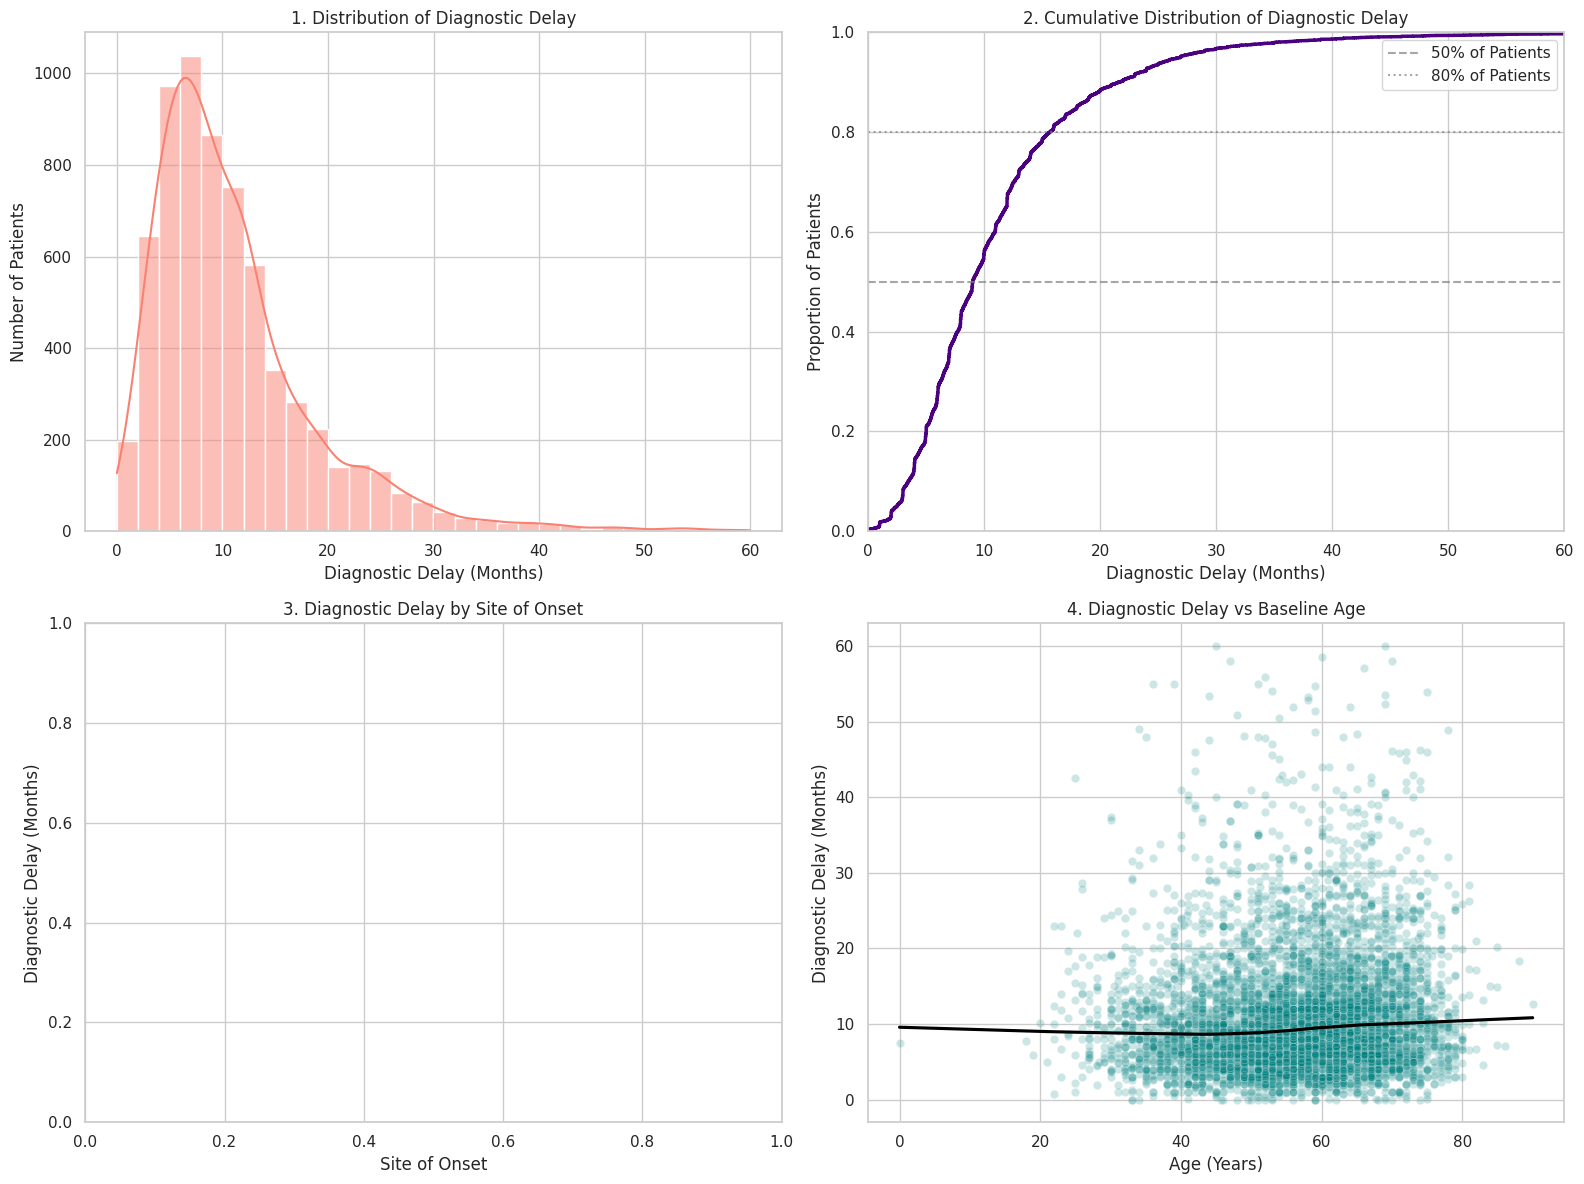

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Extracting and calculating Diagnostic Delay...")

# Extract History and Demographics
df_hist = datasets.get('history')
df_demo = datasets.get('demographics')

if df_hist is not None:
    # Dynamically find the exact column names
    onset_site_col = [c for c in df_hist.columns if 'site' in c.lower()][0]
    onset_delta_col = [c for c in df_hist.columns if 'onset_delta' in c.lower() or ('onset' in c.lower() and 'delta' in c.lower())][0]
    diag_delta_col = [c for c in df_hist.columns if 'diagnosis_delta' in c.lower() or ('diag' in c.lower() and 'delta' in c.lower())][0]
    
    # Clean the dataframe: drop missing dates and deduplicate by subject
    df_delay = df_hist[['subject_id', onset_site_col, onset_delta_col, diag_delta_col]].copy()
    df_delay = df_delay.dropna(subset=[onset_delta_col, diag_delta_col]).drop_duplicates(subset=['subject_id'])
    
    # Calculate delay in months (Diagnosis Delta - Onset Delta)
    df_delay['Diagnostic_Delay_Months'] = (df_delay[diag_delta_col] - df_delay[onset_delta_col]) / 30.44
    
    # Filter out impossible negative delays (data entry errors) and extreme outliers (> 120 months)
    df_delay = df_delay[(df_delay['Diagnostic_Delay_Months'] >= 0) & (df_delay['Diagnostic_Delay_Months'] <= 120)].copy()

    # Merge with Age from demographics for the scatter plot
    if df_demo is not None:
        age_col = [c for c in df_demo.columns if 'age' in c.lower()][0]
        df_delay = df_delay.merge(df_demo[['subject_id', age_col]].drop_duplicates(), on='subject_id', how='left')
        df_delay.rename(columns={age_col: 'Age'}, inplace=True)

    # Clean up 'Site of Onset' strings to just 'Bulbar' vs 'Limb'
    df_delay['Site_Clean'] = df_delay[onset_site_col].astype(str).apply(
        lambda x: 'Bulbar' if 'bulbar' in x.lower() else ('Limb' if 'limb' in x.lower() or 'spine' in x.lower() else 'Other')
    )

    # ==========================================
    # GENERATE THE 2x2 PLOT GRID
    # ==========================================
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    axes = axes.flatten()
    sns.set_theme(style="whitegrid")

    # Plot 1: Histogram / KDE (Clipped at 60 months for detail)
    # Most diagnoses happen within the first 5 years, so we zoom in on 0-60 months
    sns.histplot(data=df_delay[df_delay['Diagnostic_Delay_Months'] <= 60], 
                 x='Diagnostic_Delay_Months', kde=True, ax=axes[0], color='salmon', bins=30)
    axes[0].set_title('1. Distribution of Diagnostic Delay')
    axes[0].set_xlabel('Diagnostic Delay (Months)')
    axes[0].set_ylabel('Number of Patients')

    # Plot 2: Cumulative Distribution
    sns.ecdfplot(data=df_delay, x='Diagnostic_Delay_Months', ax=axes[1], color='indigo', linewidth=2.5)
    axes[1].axhline(0.5, color='gray', linestyle='--', alpha=0.7, label='50% of Patients')
    axes[1].axhline(0.8, color='gray', linestyle=':', alpha=0.7, label='80% of Patients')
    axes[1].set_title('2. Cumulative Distribution of Diagnostic Delay')
    axes[1].set_xlabel('Diagnostic Delay (Months)')
    axes[1].set_ylabel('Proportion of Patients')
    axes[1].set_xlim(0, 60)
    axes[1].legend()

    # Plot 3: Delay by Site of Onset (Violin Plot)
    df_filtered_site = df_delay[df_delay['Site_Clean'].isin(['Bulbar', 'Limb'])]
    sns.violinplot(data=df_filtered_site[df_filtered_site['Diagnostic_Delay_Months'] <= 60], 
                   x='Site_Clean', y='Diagnostic_Delay_Months', ax=axes[2], palette='Set2', inner='quartile')
    axes[2].set_title('3. Diagnostic Delay by Site of Onset')
    axes[2].set_xlabel('Site of Onset')
    axes[2].set_ylabel('Diagnostic Delay (Months)')

    # Plot 4: Scatter Plot of Age vs Delay
    if 'Age' in df_delay.columns:
        sns.scatterplot(data=df_delay[df_delay['Diagnostic_Delay_Months'] <= 60], 
                        x='Age', y='Diagnostic_Delay_Months', ax=axes[3], alpha=0.2, color='teal')
        # Add LOESS trendline
        sns.regplot(data=df_delay[df_delay['Diagnostic_Delay_Months'] <= 60], 
                    x='Age', y='Diagnostic_Delay_Months', ax=axes[3], scatter=False, color='black', lowess=True)
        axes[3].set_title('4. Diagnostic Delay vs Baseline Age')
        axes[3].set_xlabel('Age (Years)')
        axes[3].set_ylabel('Diagnostic Delay (Months)')
    else:
        axes[3].set_visible(False)

    plt.tight_layout()
    plt.show()

else:
    print("Error: The 'history' dataset could not be found.")